# Importation du dataset

In [5]:
import kagglehub
path = kagglehub.dataset_download("jangedoo/utkface-new")

100%|██████████| 331M/331M [00:02<00:00, 130MB/s]

Extracting files...


#Vérification des versions


In [6]:
#Version de Python
import sys
sys.version

'3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]'

In [7]:
#Version de tenshorflow
import tensorflow as tf
tf.__version__

'2.20.0'

In [ ]:
#Version de Keras associé
tf.keras.__version__

'3.13.2'

# Inspection et création du dataset

In [8]:
import os
# chemin vers les images : path

images = os.listdir(path)

print("Nombre d'images :", len(images))
print(images[:10])

Nombre d'images : 3
['utkface_aligned_cropped', 'crop_part1', 'UTKFace']


##Construction du dataframe

In [9]:
import os
import pandas as pd

image_dir = os.path.join(path, "UTKFace") # fait image_dir = path + UTKFace

rows = [] # pour stocker les infos de chaque image

for filename in os.listdir(image_dir): # os.listdir() signifie :

                                       #"Donne-moi tous les fichiers du dossier."

    try:
        age, gender, race = filename.split("_")[:3]

        rows.append({
            "filepath": os.path.join(image_dir, filename),
            "age": int(age),
            "gender": int(gender)
        })

    except:
        pass # afin de passer pour les noms incorect directement à la prochaine itération

df = pd.DataFrame(rows) # tranformation en dataframe

df.head() # aperçu du début du dataframe

,filepath,age,gender
0,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,21,1
1,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,26,1
2,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,22,1
3,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,32,0
4,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,29,1


###Vérificationsdes infos du dataframe

In [10]:
print(df.shape)
df.describe()


(23708, 3)


,age,gender
count,23708.000000,23708.000000
mean,33.303484,0.477349
std,19.886112,0.499497
min,1.000000,0.000000
25%,23.000000,0.000000
50%,29.000000,0.000000
75%,45.000000,1.000000
max,116.000000,1.000000


In [ ]:
#Autres infos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  23708 non-null  object
 1   age       23708 non-null  int64 
 2   gender    23708 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 555.8+ KB


#Vérifiaction des classes et leurs attributions

In [ ]:
#Vérification des classes
print(df['gender'].value_counts())
#Attributions
print(df['gender'].map({0: 'Homme', 1: 'Femme'}).value_counts())

gender
0    12391
1    11317
Name: count, dtype: int64
gender
Homme    12391
Femme    11317
Name: count, dtype: int64


#Vérification des âges

##Vérification rapide

In [ ]:
# Vérification rapide
print(df['age'].value_counts())


age
26     2197
1      1123
28      918
35      880
24      859
       ... 
115       3
101       2
91        2
111       1
103       1
Name: count, Length: 104, dtype: int64


In [ ]:
import matplotlib.pyplot as plt


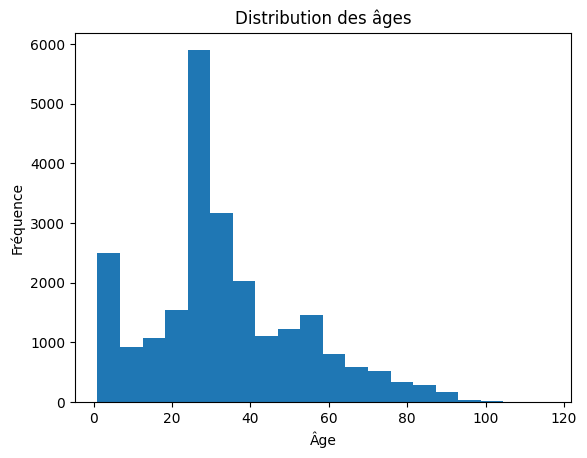

In [ ]:
plt.hist(df['age'], bins=20)
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.title('Distribution des âges')
plt.show()

Ce graphe montre que l'âge dominant est bien environ de 33 ans comme l'indique le

```
# df.describe()
```

 et sa fréquence environ 6000 occurencesm

#Traitement des images

In [ ]:
'''
import numpy as np
import cv2
def load_images(df, size = (128, 128)):

  images = []

  for image in df['filepath']:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Récupération des images avec le chemin
    img = cv2.resize(img, size)
    img = img / 255.0 #Normalisation
    images.append(img)

  return np.array(images)

'''



"\nimport numpy as np\nimport cv2\ndef load_images(df, size = (128, 128)):\n\n  images = []\n  \n  for image in df['filepath']:\n    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Récupération des images avec le chemin\n    img = cv2.resize(img, size)\n    img = img / 255.0 #Normalisation\n    images.append(img)\n\n  return np.array(images)\n\n"

#Séparer Train / Validation / Test

La répartition est la suivante :

> 70 % : entraînement

> 15 % : validation

>15 % : test



In [11]:
from sklearn.model_selection import train_test_split #importation d'une fonction qui sert à mélanger les données puis à les séparer automatiquement.

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

16595
3556
3557


##Vérifier que les trois ensembles sont corrects

In [ ]:
print(train_df.head())

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

                                                filepath  age  gender
6045   /kaggle/input/utkface-new/UTKFace/1_0_1_201701...    1       0
7503   /kaggle/input/utkface-new/UTKFace/20_1_2_20170...   20       1
12843  /kaggle/input/utkface-new/UTKFace/37_0_3_20170...   37       0
14525  /kaggle/input/utkface-new/UTKFace/18_1_1_20170...   18       1
9728   /kaggle/input/utkface-new/UTKFace/26_0_1_20170...   26       0
(16595, 3)
(3556, 3)
(3557, 3)


Cela montre que tout est correcte

#Load des images pour chaque ensemble

In [ ]:
# ============================================================
# IMPORTATION DE TENSORFLOW
# ============================================================

import tensorflow as tf

# ============================================================
# ÉTAPE 2 : DÉFINIR LES PARAMÈTRES DU PROJET
# ============================================================

# Taille à laquelle toutes les images seront redimensionnées.
# Les CNN exigent que toutes les images aient les mêmes dimensions.
IMG_HEIGHT = 128
IMG_WIDTH = 128

# Nombre d'images envoyées au modèle à chaque itération.
# 32 est une valeur classique qui offre un bon compromis entre
# vitesse d'entraînement et consommation mémoire.
BATCH_SIZE = 32

# Permet à TensorFlow d'optimiser automatiquement le chargement
# des données en arrière-plan.
AUTOTUNE = tf.data.AUTOTUNE


# ============================================================
# ÉTAPE 3 : FONCTION DE PRÉTRAITEMENT
# ============================================================

def preprocess_image(filepath, age, gender):
    """
    Cette fonction reçoit :
        - le chemin d'une image
        - son âge
        - son genre

    Elle retourne :
        - l'image prétraitée
        - les deux labels (âge et genre)
    """

    # Lire le fichier image depuis le disque
    image = tf.io.read_file(filepath)

    # Transformer le fichier JPEG en matrice de pixels (RGB)
    image = tf.image.decode_jpeg(image, channels=3)

    # Redimensionner toutes les images à 128x128
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])

    # Normaliser les pixels entre 0 et 1
    image = image / 255.0

    # Retourner :
    # - l'image
    # - les deux sorties attendues par le futur modèle
    return image, {
        "age": age,
        "gender": gender
    }


# ============================================================
# ÉTAPE 4 : CRÉATION DES DATASETS
# ============================================================

# Création du Dataset d'entraînement
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["age"].values,
        train_df["gender"].values
    )
)

# Création du Dataset de validation
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_df["age"].values,
        val_df["gender"].values
    )
)

# Création du Dataset de test
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_df["age"].values,
        test_df["gender"].values
    )
)


# ============================================================
# ÉTAPE 5 : APPLIQUER LE PRÉTRAITEMENT
# ============================================================

# Pour chaque image du Dataset,
# TensorFlow exécutera automatiquement preprocess_image().
train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)


# ============================================================
# ÉTAPE 6 : MÉLANGER LES DONNÉES D'ENTRAÎNEMENT
# ============================================================

# Mélanger les images évite que le modèle apprenne
# dans un ordre particulier (par exemple tous les bébés,
# puis tous les adultes...).
# Cette opération est appliquée uniquement au jeu d'entraînement.
train_dataset = train_dataset.shuffle(buffer_size=1000)


# ============================================================
# ÉTAPE 7 : CRÉER LES BATCHS
# ============================================================

# Regrouper les images par paquets de 32.
# Le modèle apprendra sur un batch à la fois.
train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)


# ============================================================
# ÉTAPE 8 : OPTIMISER LE CHARGEMENT
# ============================================================

# Pendant que le modèle entraîne un batch,
# TensorFlow prépare déjà le suivant.
# Cela réduit les temps d'attente.
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


# ============================================================
# ÉTAPE 9 : VÉRIFICATION
# ============================================================

# Afficher la structure du premier batch
for images, labels in train_dataset.take(1):

    print("Dimensions des images :", images.shape)

    print("Dimensions des âges :", labels["age"].shape)

    print("Dimensions des genres :", labels["gender"].shape)

Dimensions des images : (32, 128, 128, 3)
Dimensions des âges : (32,)
Dimensions des genres : (32,)


#Création du CNN

In [ ]:
# ==========================================================
# IMPORTS
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ==========================================================
# ENTRÉE DU MODÈLE
# ==========================================================

# On indique à Keras que toutes les images ont une taille
# de 128x128 pixels et possèdent 3 canaux de couleur (RGB).

inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="image"
)

# ==========================================================
# BLOC 1
# ==========================================================

# 32 filtres de taille 3x3
# Cette couche apprend à détecter des éléments simples
# comme les contours ou les lignes.

x = layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(inputs)

# Une deuxième convolution permet d'extraire
# des caractéristiques plus riches.

x = layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(x)

# Réduction de la taille de l'image
# afin de diminuer le nombre de calculs.

x = layers.MaxPooling2D(pool_size=(2,2))(x)

# ==========================================================
# BLOC 2
# ==========================================================

# On augmente progressivement le nombre de filtres.
# Le réseau apprend maintenant des structures
# plus complexes (yeux, bouche, nez...).

x = layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(x)

x = layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(pool_size=(2,2))(x)

# ==========================================================
# BLOC 3
# ==========================================================

# Encore plus de filtres.
# Les dernières couches apprennent des caractéristiques
# très abstraites du visage.

x = layers.Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation="relu",
    padding="same"
)(x)

# ==========================================================
# GLOBAL AVERAGE POOLING
# ==========================================================

# Cette couche transforme les cartes de caractéristiques
# en un vecteur beaucoup plus petit.
# Elle réduit énormément le nombre de paramètres.

x = layers.GlobalAveragePooling2D()(x)

# ==========================================================
# COUCHE DENSE COMMUNE
# ==========================================================

# Cette couche combine toutes les caractéristiques
# extraites par le CNN.

x = layers.Dense(
    128,
    activation="relu"
)(x)

# Dropout :
# Pendant l'entraînement, 30 % des neurones sont ignorés
# aléatoirement.
# Cela aide à éviter le surapprentissage (overfitting).

x = layers.Dropout(0.3)(x)


##Les sorties

In [ ]:

# ==========================================================
# PREMIÈRE SORTIE : ÂGE
# ==========================================================

# Une seule valeur numérique sera prédite.

age_output = layers.Dense(
    1,
    activation="linear",
    name="age"
)(x)

# ==========================================================
# DEUXIÈME SORTIE : GENRE
# ==========================================================

# Une probabilité comprise entre 0 et 1.

gender_output = layers.Dense(
    1,
    activation="sigmoid",
    name="gender"
)(x)


##Construction, compilation et affichage

In [ ]:

# ==========================================================
# CONSTRUCTION DU MODÈLE
# ==========================================================

model = keras.Model(
    inputs=inputs,
    outputs=[age_output, gender_output],
    name="AgeGenderCNN"
)

# ==========================================================
# AFFICHAGE DU MODÈLE
# ==========================================================

model.summary()

# ==========================================================
# COMPILATION
# ==========================================================

# Optimiseur :
# Adam est l'un des plus utilisés en Deep Learning.

model.compile(

    optimizer="adam",

    # Une fonction de perte différente
    # pour chacune des sorties.

    loss={
        "age": "mse",
        "gender": "binary_crossentropy"
    },

    # Les métriques affichées pendant l'entraînement.

    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    }

)



Model: "AgeGenderCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_4[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 156,194 (610.13 KB)

 Trainable params: 156,194 (610.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

print("GPU disponible :", tf.config.list_physical_devices('GPU'))

GPU disponible : []


In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

#Entrainement

In [ ]:
# ==========================================================
# ENTRAÎNEMENT
# ==========================================================

history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=20

)



Epoch 1/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 984s 2s/step - age_loss: 413.1852 - age_mae: 15.6488 - gender_accuracy: 0.5005 - gender_loss: 0.9619 - loss: 413.9331 - val_age_loss: 383.8269 - val_age_mae: 14.2964 - val_gender_accuracy: 0.4750 - val_gender_loss: 0.6962 - val_loss: 380.1027
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 977s 2s/step - age_loss: 385.5905 - age_mae: 15.0924 - gender_accuracy: 0.5106 - gender_loss: 0.7086 - loss: 386.2982 - val_age_loss: 362.2444 - val_age_mae: 15.2298 - val_gender_accuracy: 0.4750 - val_gender_loss: 0.7040 - val_loss: 357.6011
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 983s 2s/step - age_loss: 354.8393 - age_mae: 14.5539 - gender_accuracy: 0.5184 - gender_loss: 0.6958 - loss: 355.6284 - val_age_loss: 307.9666 - val_age_mae: 13.3968 - val_gender_accuracy: 0.4848 - val_gender_loss: 0.6919 - val_loss: 302.9801
Epoch 4/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 974s 2s/step - age_loss: 320.1141 - age_mae: 13.8041 - gender_accuracy: 0.5223 - gender_loss: 0.6949 - loss: 32

#Evaluation

In [ ]:
# ==========================================================
# ÉVALUATION
# ==========================================================

model.evaluate(test_dataset)

112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 518ms/step - age_loss: 145.4681 - age_mae: 9.1441 - gender_accuracy: 0.6311 - gender_loss: 0.6600 - loss: 146.5020


[146.50196838378906,
 145.46810913085938,
 0.6600231528282166,
 9.144135475158691,
 0.6311498284339905]

In [ ]:
model.save("AgeGenderCNN.keras")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!find "/content/drive/MyDrive" -maxdepth 2 -type d

/content/drive/MyDrive
/content/drive/MyDrive/Google AI Studio (1)
/content/drive/MyDrive/Google AI Studio
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Produit-Vacances


In [ ]:
model.save("/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN.keras")

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/history.csv",
    index=False
)

#Reprendre le modèle sauvegarder

In [ ]:
from tensorflow import keras

model = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN.keras"
)

# Vérifier que le modèle est bien chargé
model.summary()

Model: "AgeGenderCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_4[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 468,584 (1.79 MB)

 Trainable params: 156,194 (610.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 312,390 (1.19 MB)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow import keras

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), #changement du learning rate pour améliorer

    loss={
        "age": "mse",
        "gender": "binary_crossentropy"
    },

    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    }
)

#Courbe de l'ancien apprentissage

In [ ]:
#Récupération de l'historique sauvegardée
import pandas as pd

history_df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/history.csv"
)

In [ ]:
# ==========================================================
# IMPORTS
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# CHARGEMENT DE L'HISTORIQUE
# ==========================================================

# Lecture du fichier CSV contenant toutes les métriques
# enregistrées pendant l'entraînement.

history_df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/history.csv"
)

# Affichage des colonnes disponibles
print(history_df.columns)

Index(['age_loss', 'age_mae', 'gender_accuracy', 'gender_loss', 'loss',
       'val_age_loss', 'val_age_mae', 'val_gender_accuracy', 'val_gender_loss',
       'val_loss'],
      dtype='object')


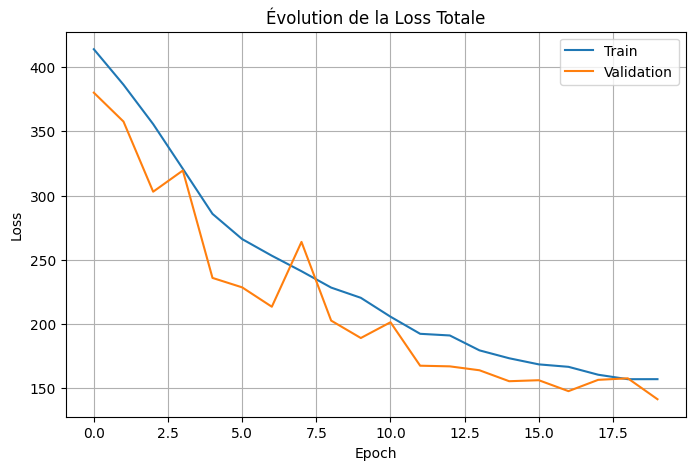

In [ ]:
# ==========================================================
# LOSS TOTALE
# ==========================================================

plt.figure(figsize=(8,5))

# Loss sur les données d'entraînement
plt.plot(
    history_df["loss"],
    label="Train"
)

# Loss sur les données de validation
plt.plot(
    history_df["val_loss"],
    label="Validation"
)

plt.title("Évolution de la Loss Totale")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

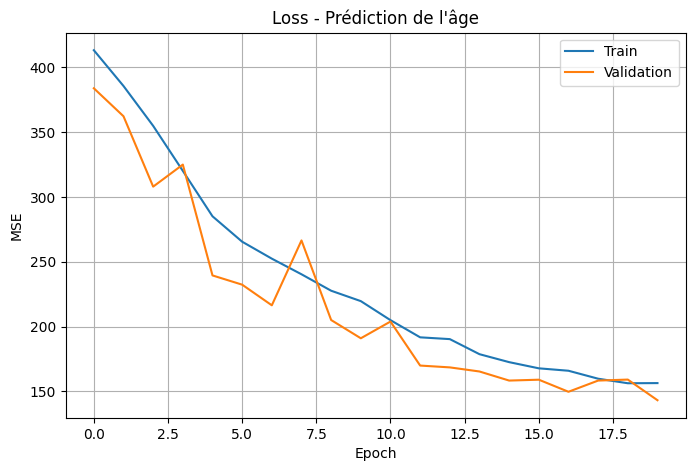

In [ ]:
# ==========================================================
# LOSS DE L'ÂGE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history_df["age_loss"],
    label="Train"
)

plt.plot(
    history_df["val_age_loss"],
    label="Validation"
)

plt.title("Loss - Prédiction de l'âge")

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.legend()

plt.grid(True)

plt.show()

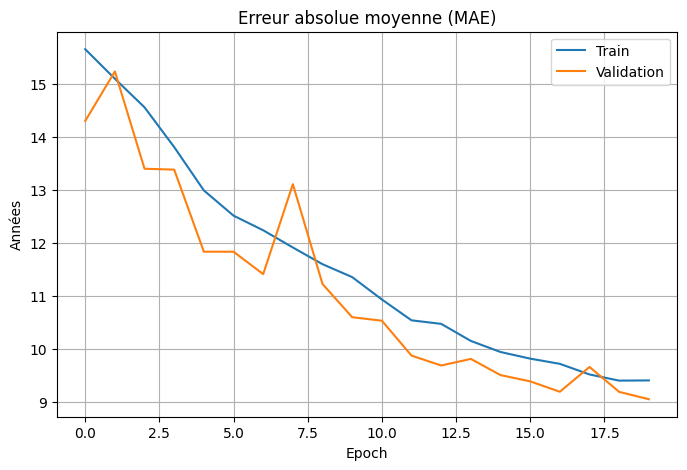

In [ ]:
# ==========================================================
# MAE DE L'ÂGE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history_df["age_mae"],
    label="Train"
)

plt.plot(
    history_df["val_age_mae"],
    label="Validation"
)

plt.title("Erreur absolue moyenne (MAE)")

plt.xlabel("Epoch")

plt.ylabel("Années")

plt.legend()

plt.grid(True)

plt.show()

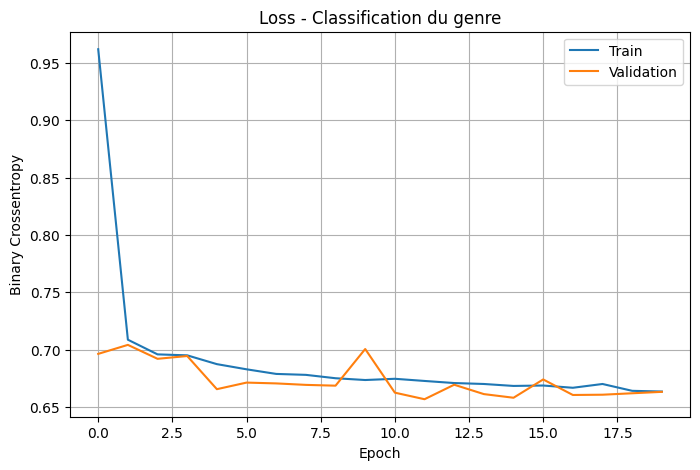

In [ ]:
# ==========================================================
# LOSS DU GENRE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history_df["gender_loss"],
    label="Train"
)

plt.plot(
    history_df["val_gender_loss"],
    label="Validation"
)

plt.title("Loss - Classification du genre")

plt.xlabel("Epoch")

plt.ylabel("Binary Crossentropy")

plt.legend()

plt.grid(True)

plt.show()

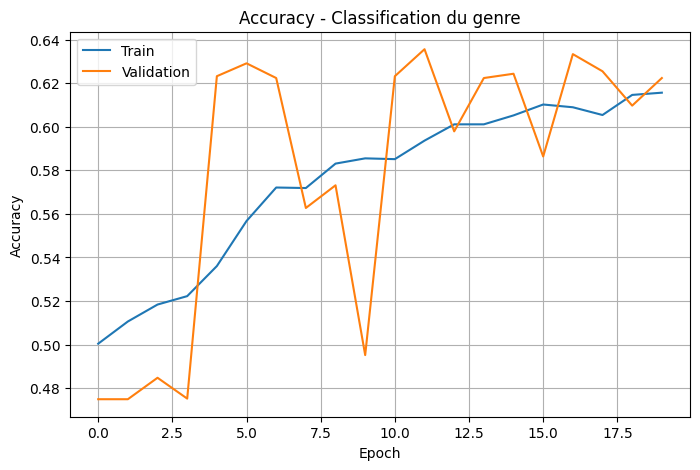

In [ ]:
# ==========================================================
# ACCURACY DU GENRE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history_df["gender_accuracy"],
    label="Train"
)

plt.plot(
    history_df["val_gender_accuracy"],
    label="Validation"
)

plt.title("Accuracy - Classification du genre")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from tensorflow import keras

# Sauvegarde automatique du meilleur modèle
checkpoint = keras.callbacks.ModelCheckpoint(

    "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v2.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

# Arrêt automatique si la validation ne s'améliore plus
early_stop = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

In [ ]:
# ==========================================================
# REPRISE DE L'ENTRAÎNEMENT
# ==========================================================

history2 = model.fit(

    train_dataset,

    validation_data=val_dataset,

    # On reprend à partir de l'époque 20
    initial_epoch=20,

    # On termine à l'époque 30
    epochs=30,

    callbacks=[
        checkpoint,
        early_stop
    ]

)

Epoch 21/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - age_loss: 140.8574 - age_mae: 8.9263 - gender_accuracy: 0.6237 - gender_loss: 0.6585 - loss: 141.5158
Epoch 21: val_loss improved from None to 118.26580, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v2.keras

Epoch 21: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v2.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 1516s 3s/step - age_loss: 138.7590 - age_mae: 8.8470 - gender_accuracy: 0.6256 - gender_loss: 0.6585 - loss: 139.3484 - val_age_loss: 118.8861 - val_age_mae: 8.0209 - val_gender_accuracy: 0.6178 - val_gender_loss: 0.6562 - val_loss: 118.2658
Epoch 22/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - age_loss: 134.5960 - age_mae: 8.6984 - gender_accuracy: 0.6319 - gender_loss: 0.6572 - loss: 135.2532
Epoch 22: val_loss did not improve from 118.26580
519/519 ━━━━━━━━━━━━━━━━━━━━ 1495s 3s/step - age_loss: 134.3305 - age_mae: 8.7006 - gender_accuracy: 0.6301 - gender_loss: 0.6569 - loss: 135

#Enregistrement de la deuxième historique

In [ ]:
# ==========================================================
# SAUVEGARDE DU MODÈLE V2
# ==========================================================

model.save(
    "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_V2.keras"
)

In [ ]:
import pandas as pd

history2_df = pd.DataFrame(history2.history)

history2_df.to_csv(

    "/content/drive/MyDrive/Colab Notebooks/history2.csv",

    index=False

)

#Création de la v3





In [ ]:
# ==========================================================
# IMPORTS
# ==========================================================

import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers


# ==========================================================
# PARAMÈTRES D'ENTRÉE
# ==========================================================

# Les images utilisées pendant l'entraînement sont :
# hauteur x largeur x canaux RGB

inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="image"
)


# ==========================================================
# DATA AUGMENTATION
# ==========================================================

data_augmentation = keras.Sequential([

    # Rotation légère
    layers.RandomRotation(0.1),

    # Miroir horizontal
    layers.RandomFlip(
        "horizontal"
    ),

    # Zoom léger
    layers.RandomZoom(
        0.1
    ),

    # Variation légère du contraste
    layers.RandomContrast(
        0.1
    )

], name="data_augmentation")


x = data_augmentation(inputs)



# ==========================================================
# BLOC 1
# ==========================================================

# Première extraction de caractéristiques.
# Le réseau apprend des éléments simples :
# contours, lignes, textures.

x = layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation("relu")(x)


# Deuxième convolution du bloc.
# Elle permet d'extraire des informations plus riches.

x = layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation("relu")(x)


# Réduction de la taille spatiale.

x = layers.MaxPooling2D(
    pool_size=(2,2)
)(x)



# ==========================================================
# BLOC 2
# ==========================================================

# Le nombre de filtres augmente.
# Le réseau apprend des formes plus complexes.

x = layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation("relu")(x)


x = layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation("relu")(x)


x = layers.MaxPooling2D(
    pool_size=(2,2)
)(x)



# ==========================================================
# BLOC 3
# ==========================================================

# Extraction de caractéristiques encore plus abstraites :
# yeux, nez, bouche, structure du visage.

x = layers.Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation("relu")(x)


x = layers.Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation("relu")(x)


x = layers.MaxPooling2D(
    pool_size=(2,2)
)(x)



# ==========================================================
# BLOC 4 : CARACTÉRISTIQUES PROFONDES
# ==========================================================

# Dernière augmentation du nombre de filtres.
# Le réseau apprend des caractéristiques très spécifiques.

x = layers.Conv2D(
    filters=256,
    kernel_size=(3,3),
    padding="same"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Activation("relu")(x)


# Nouvelle réduction spatiale.
# Cela diminue les calculs avant la classification finale.

x = layers.MaxPooling2D(
    pool_size=(2,2)
)(x)



# ==========================================================
# GLOBAL AVERAGE POOLING
# ==========================================================

# Transforme les cartes de caractéristiques en un vecteur.

# Exemple :
# 8x8x256
#
# devient :
# 256 valeurs

# Cela évite un énorme nombre de paramètres
# contrairement à Flatten.

x = layers.GlobalAveragePooling2D()(x)



# ==========================================================
# COUCHES DENSE COMMUNES
# ==========================================================

# Cette partie combine toutes les caractéristiques
# extraites par le CNN.

x = layers.Dense(
    256,
    activation="relu"
)(x)


# Désactive aléatoirement 30% des neurones
# pendant l'entraînement afin de limiter
# le surapprentissage.

x = layers.Dropout(
    0.3
)(x)


x = layers.Dense(
    128,
    activation="relu"
)(x)



# ==========================================================
# SORTIE ÂGE (RÉGRESSION)
# ==========================================================

# L'âge est une valeur numérique.
# Exemple :
# 24.5 ans

age_output = layers.Dense(
    1,
    activation="linear",
    name="age"
)(x)



# ==========================================================
# SORTIE GENRE (CLASSIFICATION)
# ==========================================================

# La sigmoid renvoie une probabilité entre 0 et 1.

gender_output = layers.Dense(
    1,
    activation="sigmoid",
    name="gender"
)(x)



# ==========================================================
# CRÉATION DU MODÈLE FINAL
# ==========================================================

model = keras.Model(

    inputs=inputs,

    outputs=[
        age_output,
        gender_output
    ],

    name="AgeGenderCNN_V3"

)



# ==========================================================
# RÉSUMÉ DU MODÈLE
# ==========================================================

model.summary()



# ==========================================================
# COMPILATION
# ==========================================================

# Adam avec learning rate explicite.
# Cela permet de contrôler précisément
# les expériences entre V1, V2 et V3.

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),


    # Deux problèmes différents :
    #
    # Age :
    # régression -> MSE
    #
    # Genre :
    # classification binaire -> Binary Crossentropy

    loss={

        "age": "mse",

        "gender": "binary_crossentropy"

    },


    # L'âge avait une loss beaucoup plus grande.
    # On réduit son poids afin que le modèle
    # prête davantage attention au genre.

    loss_weights={

        "age": 0.5,

        "gender": 1.0

    },


    # Métriques suivies pendant l'entraînement.

    metrics={

        "age": [
            "mae"
        ],

        "gender": [
            "accuracy"
        ]

    }

)

Model: "AgeGenderCNN_V3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_3[

 Total params: 683,938 (2.61 MB)

 Trainable params: 682,530 (2.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

#Entrainement de la v3

In [ ]:
history3 = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    callbacks=[

        checkpoint,

        early_stop

    ]

)

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 379.3917 - age_mae: 14.6399 - gender_accuracy: 0.5106 - gender_loss: 0.8073 - loss: 190.5031
Epoch 1: val_loss did not improve from 112.21885
519/519 ━━━━━━━━━━━━━━━━━━━━ 2717s 5s/step - age_loss: 286.2381 - age_mae: 12.9012 - gender_accuracy: 0.5273 - gender_loss: 0.7732 - loss: 143.8606 - val_age_loss: 300.9773 - val_age_mae: 12.8322 - val_gender_accuracy: 0.5014 - val_gender_loss: 0.7226 - val_loss: 150.3020
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 222.3681 - age_mae: 11.5005 - gender_accuracy: 0.5491 - gender_loss: 0.7242 - loss: 111.9084
Epoch 2: val_loss did not improve from 112.21885
519/519 ━━━━━━━━━━━━━━━━━━━━ 2718s 5s/step - age_loss: 215.7781 - age_mae: 11.2632 - gender_accuracy: 0.5619 - gender_loss: 0.7131 - loss: 108.6413 - val_age_loss: 262.2372 - val_age_mae: 11.7209 - val_gender_accuracy: 0.5661 - val_gender_loss: 0.6811 - val_loss: 131.4275
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5

In [ ]:
import pandas as pd

history3_df = pd.DataFrame(history3.history)

history3_df.to_csv(

    "/content/drive/MyDrive/Colab Notebooks/history2.csv",

    index=False

)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================================
# IMPORTS
# ==========================================================

import pandas as pd

from tensorflow import keras


# ==========================================================
# CHARGEMENT DU MEILLEUR MODÈLE
# ==========================================================

# On recharge le meilleur modèle enregistré
# par ModelCheckpoint.

model = keras.models.load_model(

    "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v2.keras"

)

print("Modèle chargé avec succès !")

Modèle chargé avec succès !


In [ ]:
# ==========================================================
# RECOMPILATION
# ==========================================================

# On garde exactement la même architecture.
#
# La seule différence est que l'on diminue
# fortement le learning rate afin de faire
# un apprentissage plus fin.

model.compile(

    optimizer=keras.optimizers.Adam(

        learning_rate=0.0001

    ),

    loss={

        "age":"mse",

        "gender":"binary_crossentropy"

    },

    loss_weights={

        "age":0.5,

        "gender":1.0

    },

    metrics={

        "age":["mae"],

        "gender":["accuracy"]

    }

)

In [ ]:
# ==========================================================
# CALLBACK : SAUVEGARDE DU MEILLEUR MODÈLE
# ==========================================================

checkpoint = keras.callbacks.ModelCheckpoint(

    filepath="/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)



# ==========================================================
# CALLBACK : EARLY STOPPING
# ==========================================================

# Cette fois on laisse davantage de temps
# au modèle.

early_stop = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

In [ ]:
# ==========================================================
# REPRISE DE L'ENTRAÎNEMENT
# ==========================================================

history_continue = model.fit(

    train_dataset,

    validation_data=val_dataset,

    # On repart après l'époque 4
    # puisque c'est celle qui avait été
    # restaurée automatiquement.

    initial_epoch=4,

    # On continue jusqu'à 20.
    # Cela signifie que le modèle
    # entraînera les époques 5 à 20.

    epochs=20,

    callbacks=[

        checkpoint,

        early_stop

    ]

)

Epoch 5/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - age_loss: 152.4546 - age_mae: 9.1748 - gender_accuracy: 0.6166 - gender_loss: 0.6586 - loss: 76.8857
Epoch 5: val_loss improved from None to 69.82181, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras

Epoch 5: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 3018s 6s/step - age_loss: 147.5507 - age_mae: 9.0083 - gender_accuracy: 0.6204 - gender_loss: 0.6586 - loss: 74.3623 - val_age_loss: 137.5430 - val_age_mae: 8.4400 - val_gender_accuracy: 0.6367 - val_gender_loss: 0.6452 - val_loss: 69.8218
Epoch 6/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 143.0809 - age_mae: 8.8286 - gender_accuracy: 0.6191 - gender_loss: 0.6566 - loss: 72.1971
Epoch 6: val_loss did not improve from 69.82181
519/519 ━━━━━━━━━━━━━━━━━━━━ 2942s 6s/step - age_loss: 140.6759 - age_mae: 8.7811 - gender_accuracy: 0.6180 - gender_loss: 0.6585 - 

In [ ]:
from tensorflow import keras

model = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras"
)

print("✅ Modèle chargé.")

✅ Modèle chargé.


In [ ]:
model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss={
        "age": "mse",
        "gender": "binary_crossentropy"
    },

    loss_weights={
        "age": 0.5,
        "gender": 1.0
    },

    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    }

)

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(

    filepath="/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

early_stop = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

In [ ]:
history_continue2 = model.fit(

    train_dataset,

    validation_data=val_dataset,

    initial_epoch=15,

    epochs=25,

    callbacks=[

        checkpoint,

        early_stop

    ]

)

Epoch 16/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 118.6090 - age_mae: 7.9543 - gender_accuracy: 0.6162 - gender_loss: 0.6594 - loss: 59.9638
Epoch 16: val_loss improved from None to 66.73118, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras

Epoch 16: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 2951s 6s/step - age_loss: 118.8240 - age_mae: 7.9637 - gender_accuracy: 0.6139 - gender_loss: 0.6589 - loss: 60.0276 - val_age_loss: 131.8534 - val_age_mae: 8.4122 - val_gender_accuracy: 0.6198 - val_gender_loss: 0.6550 - val_loss: 66.7312
Epoch 17/25
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 115.8750 - age_mae: 7.8364 - gender_accuracy: 0.6135 - gender_loss: 0.6585 - loss: 58.5960
Epoch 17: val_loss improved from 66.73118 to 64.22391, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras

Epoch 17: finished saving model t

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow import keras

model = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v3_finetuned.keras"
)

In [ ]:
model.summary()

Model: "AgeGenderCNN_V3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_3[

 Total params: 2,049,000 (7.82 MB)

 Trainable params: 682,530 (2.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 1,365,062 (5.21 MB)

In [ ]:
results = model.evaluate(test_dataset)
print(results)

112/112 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - age_loss: 93.1479 - age_mae: 6.8816 - gender_accuracy: 0.6199 - gender_loss: 0.6515 - loss: 47.3256
[47.3255729675293, 93.14786529541016, 0.6515445709228516, 6.881574630737305, 0.6199043989181519]


In [12]:
# ============================================================
# PRÉTRAITEMENT CORRIGÉ — âge normalisé pour équilibrer les losses
# ============================================================

import tensorflow as tf

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Facteur de normalisation de l'âge : ramène ~33 ans -> ~0.33
# pour que la MSE de l'âge et la BCE du genre soient du même ordre de grandeur
AGE_NORM_FACTOR = 100.0

def preprocess_image(filepath, age, gender):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0

    age_normalized = tf.cast(age, tf.float32) / AGE_NORM_FACTOR

    return image, {
        "age": age_normalized,
        "gender": gender
    }

# Datasets à partir des dataframes train_df / val_df / test_df déjà créés plus haut
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["age"].values, train_df["gender"].values)
)
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_df["filepath"].values, val_df["age"].values, val_df["gender"].values)
)
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["age"].values, test_df["gender"].values)
)

train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)

train_dataset = train_dataset.shuffle(buffer_size=1000)

train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

# Vérification rapide : l'âge doit maintenant être une petite valeur (~0.1 à ~0.9)
for images, labels in train_dataset.take(1):
    print("Dimensions des images :", images.shape)
    print("Exemple d'âges normalisés :", labels["age"].numpy()[:5])
    print("Exemple de genres :", labels["gender"].numpy()[:10])

Dimensions des images : (32, 128, 128, 3)
Exemple d'âges normalisés : [0.01 0.28 0.36 0.22 0.27]
Exemple de genres : [1 0 0 1 1 0 0 1 1 0]


In [ ]:
# ==========================================================
# MODÈLE V4 — architecture identique à la V3, loss corrigée
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="image")

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

x = data_augmentation(inputs)

# Bloc 1
x = layers.Conv2D(32, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Conv2D(32, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)

# Bloc 2
x = layers.Conv2D(64, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Conv2D(64, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)

# Bloc 3
x = layers.Conv2D(128, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Conv2D(128, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)

# Bloc 4
x = layers.Conv2D(256, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)

age_output = layers.Dense(1, activation="linear", name="age")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)

model = keras.Model(
    inputs=inputs,
    outputs=[age_output, gender_output],
    name="AgeGenderCNN_V4"
)

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "age": "mse",
        "gender": "binary_crossentropy"
    },
    loss_weights={
        "age": 1.0,
        "gender": 1.0
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    }
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history4 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[checkpoint, early_stop]
)

Model: "AgeGenderCNN_V4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_7[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_8[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_5[

 Total params: 683,938 (2.61 MB)

 Trainable params: 682,530 (2.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 0.0861 - age_mae: 0.2093 - gender_accuracy: 0.6250 - gender_loss: 0.6491 - loss: 0.7352
Epoch 1: val_loss improved from None to 0.67253, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 2678s 5s/step - age_loss: 0.0536 - age_mae: 0.1744 - gender_accuracy: 0.6503 - gender_loss: 0.6240 - loss: 0.6777 - val_age_loss: 0.0366 - val_age_mae: 0.1548 - val_gender_accuracy: 0.6530 - val_gender_loss: 0.6344 - val_loss: 0.6725
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 0.0386 - age_mae: 0.1515 - gender_accuracy: 0.7282 - gender_loss: 0.5466 - loss: 0.5852
Epoch 2: val_loss improved from 0.67253 to 0.62645, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderC

In [ ]:
rom tensorflow import keras

model = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras"
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history4_continue = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,   # nombre d'epochs supplémentaires, pas le total
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 0.0196 - age_mae: 0.1050 - gender_accuracy: 0.8706 - gender_loss: 0.2981 - loss: 0.3177
Epoch 1: val_loss improved from None to 0.33362, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 2616s 5s/step - age_loss: 0.0194 - age_mae: 0.1044 - gender_accuracy: 0.8644 - gender_loss: 0.3031 - loss: 0.3226 - val_age_loss: 0.0196 - val_age_mae: 0.1084 - val_gender_accuracy: 0.8625 - val_gender_loss: 0.3138 - val_loss: 0.3336
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 0.0183 - age_mae: 0.1015 - gender_accuracy: 0.8710 - gender_loss: 0.2897 - loss: 0.3079
Epoch 2: val_loss improved from 0.33362 to 0.30708, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderC

In [ ]:
model.save("/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4_final.keras")

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

age_mae_reel = test_results["age_mae"] * 100
print(f"Age MAE réel : {age_mae_reel:.2f} ans")

112/112 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - age_loss: 0.0205 - age_mae: 0.1118 - gender_accuracy: 0.8814 - gender_loss: 0.2719 - loss: 0.2902
{'age_loss': 0.020548095926642418, 'age_mae': 0.11181732267141342, 'gender_accuracy': 0.8813607096672058, 'gender_loss': 0.27188318967819214, 'loss': 0.29016539454460144}
Age MAE réel : 11.18 ans


In [1]:
# ============================================================
# Montage Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# ============================================================
# Rechargement du modèle V4 existant (poids déjà entraînés
# conservés, on repart de là plutôt que de zéro)
# ============================================================
import tensorflow as tf
from tensorflow import keras

MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v4.keras"

model = keras.models.load_model(MODEL_PATH)

In [3]:

# ============================================================
# Recompilation avec les ajustements décidés :
# - loss_weights du genre réduit (0.5 au lieu de 1.0)
# - learning_rate inchangé (0.001), le problème n'était pas là
# ============================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "age": "mse",
        "gender": "binary_crossentropy"
    },
    loss_weights={
        "age": 1.0,
        "gender": 0.5
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    }
)

model.summary()


Model: "AgeGenderCNN_V4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_7[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_8[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_5[

 Total params: 683,938 (2.61 MB)

 Trainable params: 682,530 (2.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:

# ============================================================
# Callbacks ajustés : patience augmentée pour laisser respirer
# la val_loss combinée (avant: patience=5, arrêt prématuré
# à l'epoch 2)
# ============================================================
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v5.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Reprise de l'entraînement
# Assure-toi que train_dataset et val_dataset sont déjà définis
# dans ta session (même pipeline de preprocessing que le V4)
# ============================================================
history5 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 0.0173 - age_mae: 0.0974 - gender_accuracy: 0.8739 - gender_loss: 0.2850 - loss: 0.1598
Epoch 1: val_loss improved from None to 0.27095, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v5.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v5.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 2953s 6s/step - age_loss: 0.0173 - age_mae: 0.0977 - gender_accuracy: 0.8751 - gender_loss: 0.2821 - loss: 0.1583 - val_age_loss: 0.0154 - val_age_mae: 0.0943 - val_gender_accuracy: 0.7694 - val_gender_loss: 0.5126 - val_loss: 0.2710
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - age_loss: 0.0172 - age_mae: 0.0973 - gender_accuracy: 0.8760 - gender_loss: 0.2850 - loss: 0.1596
Epoch 2: val_loss improved from 0.27095 to 0.14919, saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderCNN_v5.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/AgeGenderC

In [ ]:
import os
from PIL import Image

image_dir = "chemin/vers/UTKFace"  # même chemin que dans ton notebook original
filenames = os.listdir(image_dir)[:10]  # échantillon de 10 fichiers

for f in filenames:
    img = Image.open(os.path.join(image_dir, f))
    print(f, img.size)